In [2]:
pip install yfinance pandas numpy matplotlib mplfinance

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

In [17]:

tickers = ["AAPL", "GOOGL", "MSFT", "AMZN", "TSLA"]
ohlcv_data = {}

for ticker in tickers:
    stock = yf.download(ticker, period="1mo", interval="15m")
    stock.dropna(how="any", inplace=True)
    ohlcv_data[ticker] = stock

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [28]:
data = ohlcv_data["AMZN"]


def MACD(Data, fast_period=12, slow_period=26, signal_period=9):
    data = Data.copy()
    data['exp1'] = data['Close'].ewm(span=fast_period, adjust=False).mean()
    data['exp2'] = data['Close'].ewm(span=slow_period, adjust=False).mean()
    data['macd_line'] = data['exp1'] - data['exp2']
    data['signal_line'] = data['macd_line'].ewm(span=signal_period, adjust=False).mean()
    return data.loc[:,['macd_line','signal_line']]

for ticker in tickers:
    ohlcv_data[ticker][['MACD','SIGNAL']] = MACD(ohlcv_data[ticker])

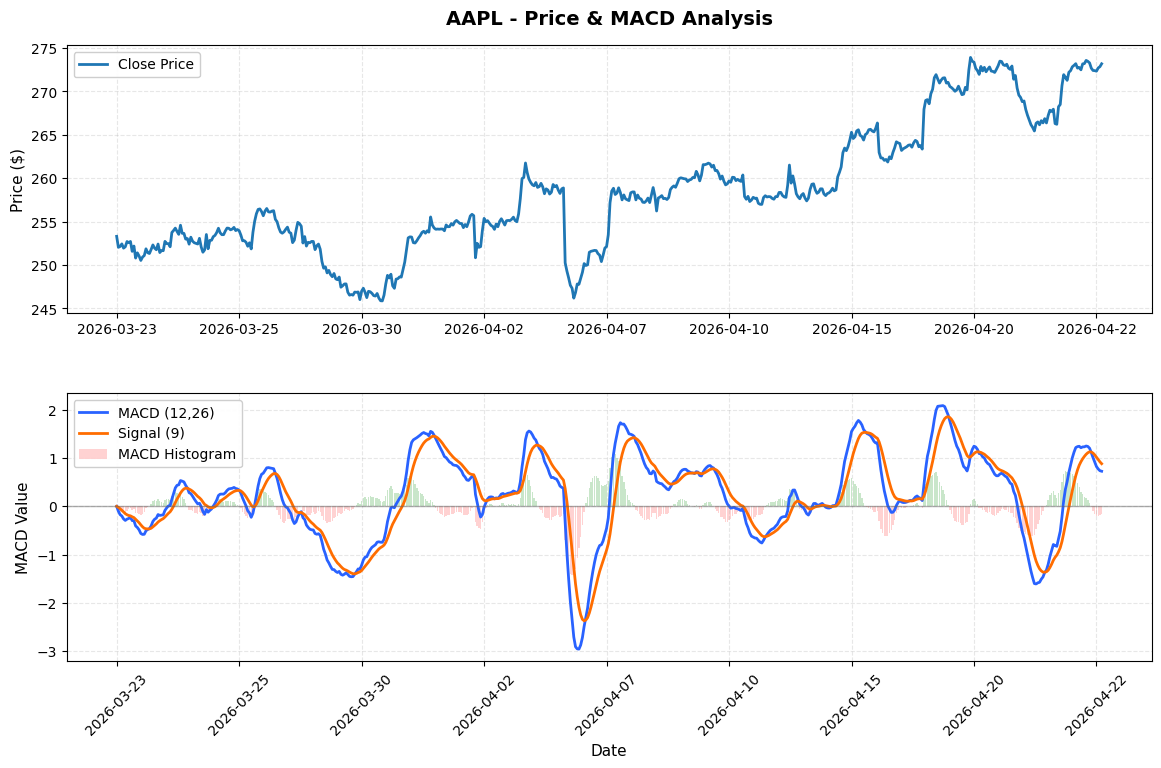

Chart displayed for AAPL


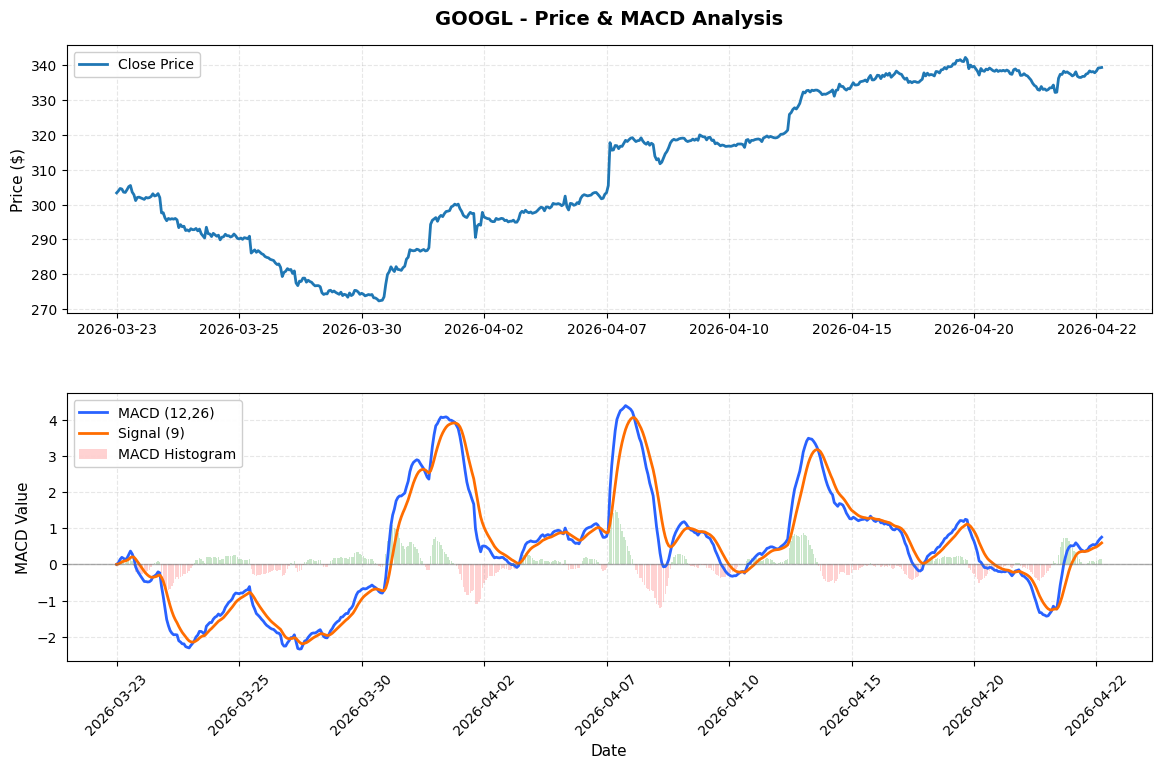

Chart displayed for GOOGL


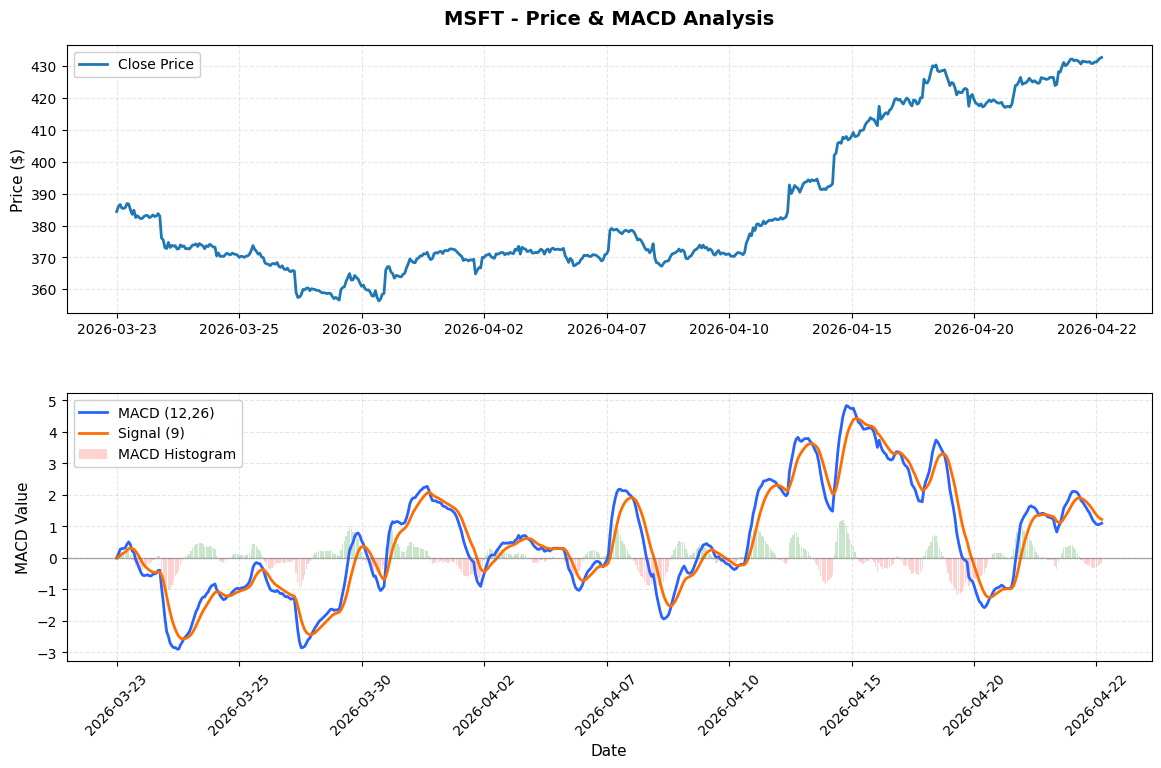

Chart displayed for MSFT


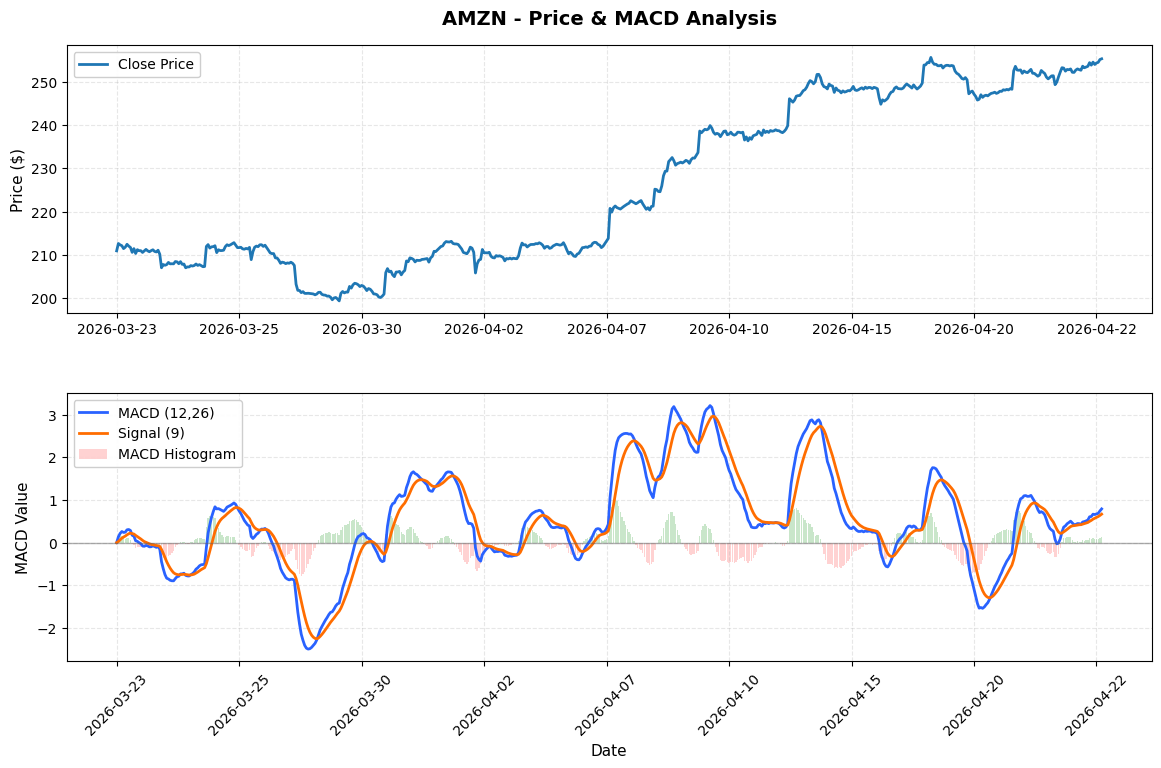

Chart displayed for AMZN


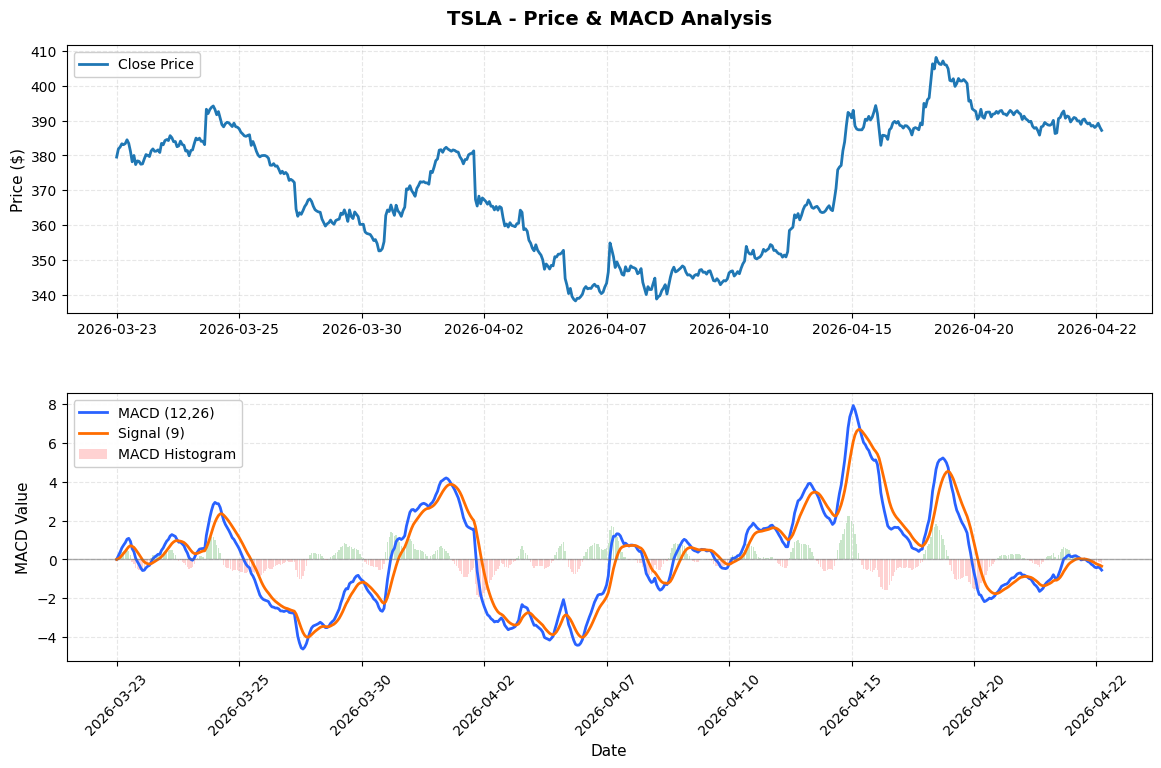

Chart displayed for TSLA


In [40]:
# MACD Visualization with Price and MACD Indicators
def plot_macd_with_price(data, ticker, figsize=(14, 8)):
    """
    Plot price chart on top and MACD/Signal lines below using actual dates.
    """
    fig = plt.figure(figsize=figsize, facecolor='white')
    gs = GridSpec(2, 1, height_ratios=[1, 1], hspace=0.3)
    
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    
    # Get dates and positions
    dates = data.index
    x_positions = np.arange(len(data))
    
    # Top panel: Price
    ax1.plot(x_positions, data['Close'], label='Close Price', color='#1f77b4', linewidth=2)
    ax1.set_title(f'{ticker} - Price & MACD Analysis', fontsize=14, fontweight='bold', pad=15)
    ax1.set_ylabel('Price ($)', fontsize=11)
    ax1.legend(loc='upper left', fontsize=10, framealpha=0.95)
    ax1.grid(True, alpha=0.3, linestyle='--')
    
    # Bottom panel: MACD and Signal lines
    ax2.plot(x_positions, data['MACD'], label='MACD (12,26)', color='#2962FF', linewidth=2)
    ax2.plot(x_positions, data['SIGNAL'], label='Signal (9)', color='#FF6D00', linewidth=2)
    
    # MACD histogram
    histogram = data['MACD'] - data['SIGNAL']
    colors = ['#4CAF50' if h > 0 else '#FF6B6B' for h in histogram]
    ax2.bar(x_positions, histogram, label='MACD Histogram', color=colors, alpha=0.3, width=0.8)
    
    # Zero line
    ax2.axhline(y=0, color='#606060', linestyle='-', linewidth=1, alpha=0.5)
    
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('MACD Value', fontsize=11)
    ax2.legend(loc='upper left', fontsize=10, framealpha=0.95)
    ax2.grid(True, alpha=0.3, linestyle='--')
    
    # Format x-axis with dates (without time)
    step = max(1, len(dates) // 8)
    ax2.set_xticks(x_positions[::step])
    date_labels = [dates[i].strftime('%Y-%m-%d') for i in range(0, len(dates), step)]
    ax2.set_xticklabels(date_labels, rotation=45)
    
    plt.tight_layout()
    return fig

# Generate visualizations for all tickers
for ticker in tickers:
    fig = plot_macd_with_price(ohlcv_data[ticker], ticker)
    plt.savefig(f"ticker_{ticker}_macd_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Chart displayed for {ticker}")

